[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mrithulashri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


MOVIE REVIEW SENTIMENT ANALYSIS

First 5 Rows
                                              review sentiment
0  I really liked this Summerslam due to the look...  positive
1  Not many television shows appeal to quite as m...  positive
2  The film quickly gets to a major chase scene w...  negative
3  Jane Austen would definitely approve of this o...  positive
4  Expectations were somewhat high for me when I ...  negative

Dataset Shape
(10000, 2)

Missing Values
review       0
sentiment    0
dtype: int64

Duplicate Values
22

Sentiment Distribution
sentiment
positive    5039
negative    4961
Name: count, dtype: int64


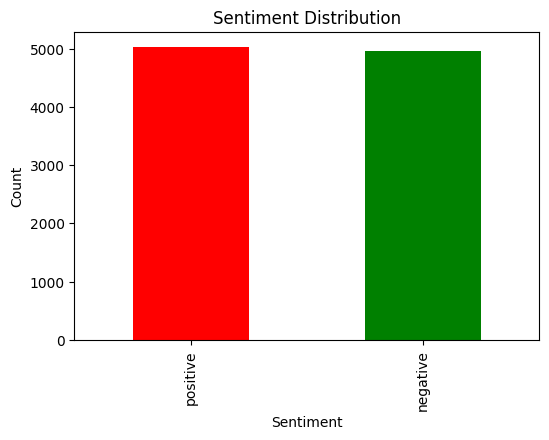


Cleaning Reviews...

Original Review
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and the He

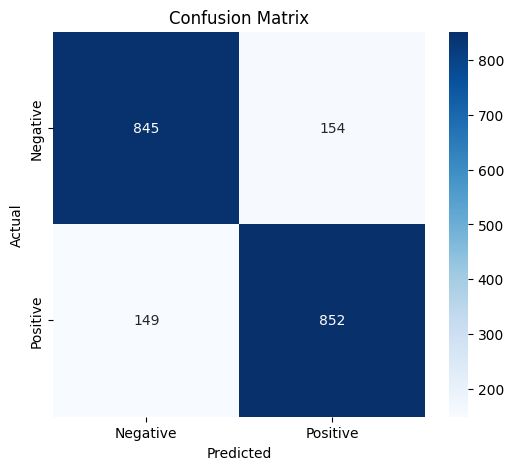


Prediction on New Reviews

Review : This movie was amazing and I loved it.
Prediction : Positive
--------------------------------------------------
Review : Worst movie ever. Waste of time.
Prediction : Negative
--------------------------------------------------
Review : Excellent acting and wonderful story.
Prediction : Positive
--------------------------------------------------
Review : The movie was boring and dull.
Prediction : Negative
--------------------------------------------------
Review : Fantastic screenplay and brilliant direction.
Prediction : Positive
--------------------------------------------------

Sentiment Analysis Completed Successfully!


In [2]:
# ==========================================================
# NLP Skill Task 2
# Movie Review Sentiment Analysis using Naive Bayes
# ==========================================================

# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Download Stopwords
# -----------------------------
nltk.download("stopwords")

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("IMDB Dataset.csv")

# Use 10,000 reviews for faster execution
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

print("="*60)
print("MOVIE REVIEW SENTIMENT ANALYSIS")
print("="*60)

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Values")
print(df.duplicated().sum())

print("\nSentiment Distribution")
print(df["sentiment"].value_counts())

# -----------------------------
# Plot Distribution
# -----------------------------
plt.figure(figsize=(6,4))

df["sentiment"].value_counts().plot(
    kind="bar",
    color=["red","green"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# -----------------------------
# Text Preprocessing
# -----------------------------
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = text.lower()

    text = re.sub(r"<.*?>","",text)

    text = text.translate(
        str.maketrans("","",string.punctuation)
    )

    text = re.sub(r"\d+","",text)

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

print("\nCleaning Reviews...")

df["clean_review"] = df["review"].apply(preprocess)

print("\nOriginal Review")
print(df["review"].iloc[0])

print("\nCleaned Review")
print(df["clean_review"].iloc[0])

# -----------------------------
# Encode Labels
# -----------------------------
df["sentiment"] = df["sentiment"].map({
    "positive":1,
    "negative":0
})

# -----------------------------
# TF-IDF
# -----------------------------
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])

y = df["sentiment"]

print("\nTF-IDF Shape :", X.shape)

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

# -----------------------------
# Train Model
# -----------------------------
model = MultinomialNB()

model.fit(X_train,y_train)

print("\nModel Training Completed")

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("\nAccuracy :",accuracy_score(y_test,y_pred))
print("Precision :",precision_score(y_test,y_pred))
print("Recall :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
# -----------------------------
# Test New Reviews
# -----------------------------
reviews = [

    "This movie was amazing and I loved it.",

    "Worst movie ever. Waste of time.",

    "Excellent acting and wonderful story.",

    "The movie was boring and dull.",

    "Fantastic screenplay and brilliant direction."

]

reviews_clean = [preprocess(i) for i in reviews]

reviews_vector = vectorizer.transform(reviews_clean)

predictions = model.predict(reviews_vector)

print("\nPrediction on New Reviews\n")

for review,pred in zip(reviews,predictions):

    if pred==1:
        sentiment="Positive"
    else:
        sentiment="Negative"

    print("Review :",review)
    print("Prediction :",sentiment)
    print("-"*50)

print("\nSentiment Analysis Completed Successfully!")